In [1]:
import sys
from pathlib import Path

# Add repo root to Python path
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
# Imports
import pandas as pd
from src.data import load_raw_csv
from src.prep import prepare_complaints_df, stratified_cap_per_class, time_split

TEXT_COL = "narrative"
LABEL_COL = "Product"
DATE_COL  = "Date received"

df = load_raw_csv("../data/raw")
df = prepare_complaints_df(df, text_col=TEXT_COL, label_col=LABEL_COL, date_col=DATE_COL, min_chars=20)

# Keep top 10 products
top_n = 10
top_labels = df[LABEL_COL].value_counts().head(top_n).index
df = df[df[LABEL_COL].isin(top_labels)].copy()

# Cap per class (16GB safe starting point)
CAP_PER_CLASS = 10000
SEED = 42
df_small = stratified_cap_per_class(df, label_col=LABEL_COL, cap_per_class=CAP_PER_CLASS, random_state=SEED)

print("Sampled shape:", df_small.shape)
print(df_small[LABEL_COL].value_counts())

# Time split
train, test = time_split(df_small, date_col=DATE_COL, train_frac=0.8)
X_train, y_train = train["text_clean"], train[LABEL_COL]
X_test,  y_test  = test["text_clean"],  test[LABEL_COL]
print("Train/Test:", len(train), len(test))


Sampled shape: (100000, 4)
Product
Checking or savings account                                                     10000
Credit card                                                                     10000
Credit card or prepaid card                                                     10000
Credit reporting or other personal consumer reports                             10000
Credit reporting, credit repair services, or other personal consumer reports    10000
Debt collection                                                                 10000
Money transfer, virtual currency, or money service                              10000
Mortgage                                                                        10000
Student loan                                                                    10000
Vehicle loan or lease                                                           10000
Name: count, dtype: int64
Train/Test: 80000 20000


C:\Users\praty\OneDrive\Documents\GitHub\Consumer-Complaints-LLM-Analysis\src\prep.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), cap_per_class), random_state=random_state))


In [3]:
# TF-IDF + SGD Classifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score, classification_report

tfidf_sgd = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=60000,   # safer than 80k for 16GB
        ngram_range=(1,2),
        min_df=10            # reduces vocab a lot on huge corpora
    )),
    ("sgd", SGDClassifier(
        loss="log_loss",
        max_iter=25,
        tol=1e-3,
        n_jobs=-1,
        random_state=42
    ))
])

tfidf_sgd.fit(X_train, y_train)
pred = tfidf_sgd.predict(X_test)

macro = f1_score(y_test, pred, average="macro")
weighted = f1_score(y_test, pred, average="weighted")

print("TF-IDF + SGD Macro F1:", macro)
print("TF-IDF + SGD Weighted F1:", weighted)
print(classification_report(y_test, pred))

TF-IDF + SGD Macro F1: 0.461719258013692
TF-IDF + SGD Weighted F1: 0.3169004173177168
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.67      0.74      0.71      1659
                                                                 Credit card       0.77      0.09      0.17      4513
                                                 Credit card or prepaid card       0.00      0.00      0.00         0
                         Credit reporting or other personal consumer reports       1.00      0.00      0.00      7800
Credit reporting, credit repair services, or other personal consumer reports       0.00      0.00      0.00         0
                                                             Debt collection       0.53      0.49      0.51      1396
                          Money transfer, virtual currency, or money service       0.72

c:\Users\praty\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praty\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praty\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

C:\Users\praty\AppData\Local\Temp\ipykernel_8356\582374062.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


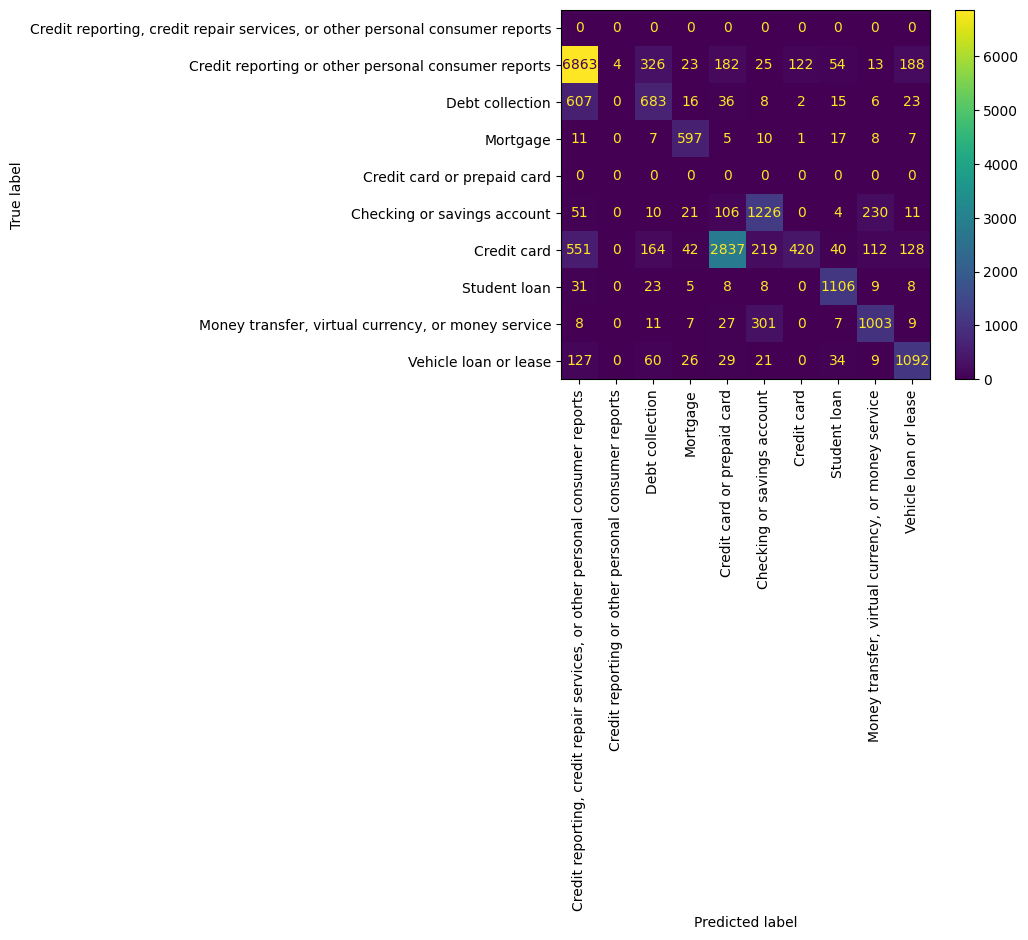

In [4]:
# Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = list(top_labels)
ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    labels=labels,
    xticks_rotation=90
)
plt.tight_layout()
plt.show()

In [5]:
# Save Baseline Metrics
from pathlib import Path
import pandas as pd

Path("../reports").mkdir(exist_ok=True)

baseline_metrics = pd.DataFrame([{
    "model": "TF-IDF + SGD(log_loss)",
    "macro_f1": macro,
    "weighted_f1": weighted,
    "top_n_products": top_n,
    "cap_per_class": CAP_PER_CLASS,
    "vectorizer": "TF-IDF (1-2 grams, max_features=60000, min_df=10)",
    "split": "time split 80/20"
}])

baseline_metrics.to_csv("../reports/baseline_metrics.csv", index=False)
baseline_metrics

,model,macro_f1,weighted_f1,top_n_products,cap_per_class,vectorizer,split
0,TF-IDF + SGD(log_loss),0.461719,0.3169,10,10000,"TF-IDF (1-2 grams, max_features=60000, min_df=10)",time split 80/20
